# 02 — Feature Engineering & Target Construction

Builds the modelling table: one row per customer, 11 features from the observation window
and the 90-day forward spend target.

The whole notebook turns on a single parameter, the cutoff date. Features may read only
transactions before it; the target may read only transactions after it. This is asserted
in code below rather than left as an assumption.

**Outputs:** `data/customer_features.csv`, figures 05–08 in `reports/figures/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_prep import FIGURES_DIR, load_clean_transactions
from src.features import (
    CUSTOMER_DATASET_PATH,
    CUTOFF_DATE,
    FEATURE_COLUMNS,
    PREDICTION_WINDOW_DAYS,
    TARGET_COLUMN,
    build_customer_dataset,
    build_features,
    build_target,
    split_windows,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200, "display.max_columns", 40)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=150, bbox_inches="tight")


transactions = load_clean_transactions()
print(f"clean transactions : {len(transactions):,} rows")
print(f"cutoff             : {CUTOFF_DATE.date()}")
print(f"prediction horizon : {PREDICTION_WINDOW_DAYS} days")

clean transactions : 776,596 rows
cutoff             : 2011-09-01
prediction horizon : 90 days


## 1. Splitting the observation and prediction windows

Everything before the cutoff is history the model may learn from. The 90 days after it are
the future being predicted. The comparison is strict (`<` cutoff), so no transaction can
sit in both.

In [2]:
observation, prediction = split_windows(transactions)

# Guardrails, not decoration: if either assertion ever fails the target is contaminated
# and every metric downstream becomes meaningless.
assert observation["InvoiceDate"].max() < CUTOFF_DATE
assert prediction["InvoiceDate"].min() >= CUTOFF_DATE
assert prediction["InvoiceDate"].max() < CUTOFF_DATE + pd.Timedelta(days=PREDICTION_WINDOW_DAYS)

print(f"observation : {len(observation):>7,} rows  "
      f"{observation['InvoiceDate'].min().date()} -> {observation['InvoiceDate'].max().date()}")
print(f"prediction  : {len(prediction):>7,} rows  "
      f"{prediction['InvoiceDate'].min().date()} -> {prediction['InvoiceDate'].max().date()}")
print("\nwindow separation verified")

observation : 608,572 rows  2009-12-01 -> 2011-08-31
prediction  : 148,968 rows  2011-09-01 -> 2011-11-29

window separation verified


## 2. Population and target

The modelled population is every customer with at least one valid purchase **before** the
cutoff. Membership is decided entirely by history, so a customer never enters or leaves the
dataset because of what they did afterwards.

Customers who buy nothing in the next 90 days get a target of 0 and are kept. They are the
majority, and they are exactly the customers a retention campaign needs to identify —
dropping them would turn the problem into "how much do returning customers spend", which is
a different and far less useful question.

In [3]:
features = build_features(observation, CUTOFF_DATE)
target = build_target(prediction, features.index)
dataset = features.join(target)

print(f"customers in population : {len(dataset):,}")
print(f"zero-spend customers    : {(dataset[TARGET_COLUMN] == 0).sum():,} "
      f"({(dataset[TARGET_COLUMN] == 0).mean():.1%})")
print(f"mean future_clv         : {dataset[TARGET_COLUMN].mean():,.2f}")
print(f"median future_clv       : {dataset[TARGET_COLUMN].median():,.2f}")
print(f"max future_clv          : {dataset[TARGET_COLUMN].max():,.2f}")

customers in population : 5,224
zero-spend customers    : 2,988 (57.2%)
mean future_clv         : 515.02
median future_clv       : 0.00
max future_clv          : 117,634.53


In [4]:
# Customers appearing only after the cutoff are newly acquired and have no history to
# predict from, so they are correctly absent from the population.
post_only = set(prediction["Customer ID"]) - set(observation["Customer ID"])
print(f"post-cutoff-only customers excluded from the population: {len(post_only):,}")

post-cutoff-only customers excluded from the population: 597


## 3. Target distribution — raw and log1p

The raw target is zero-inflated and extremely right-skewed. Training directly on it would
let a handful of very large customers dominate the loss.

`log1p` compresses that range; `expm1` inverts it at prediction time. `log1p` rather than
`log` because zero is a legitimate and very common value here, not a missing one.

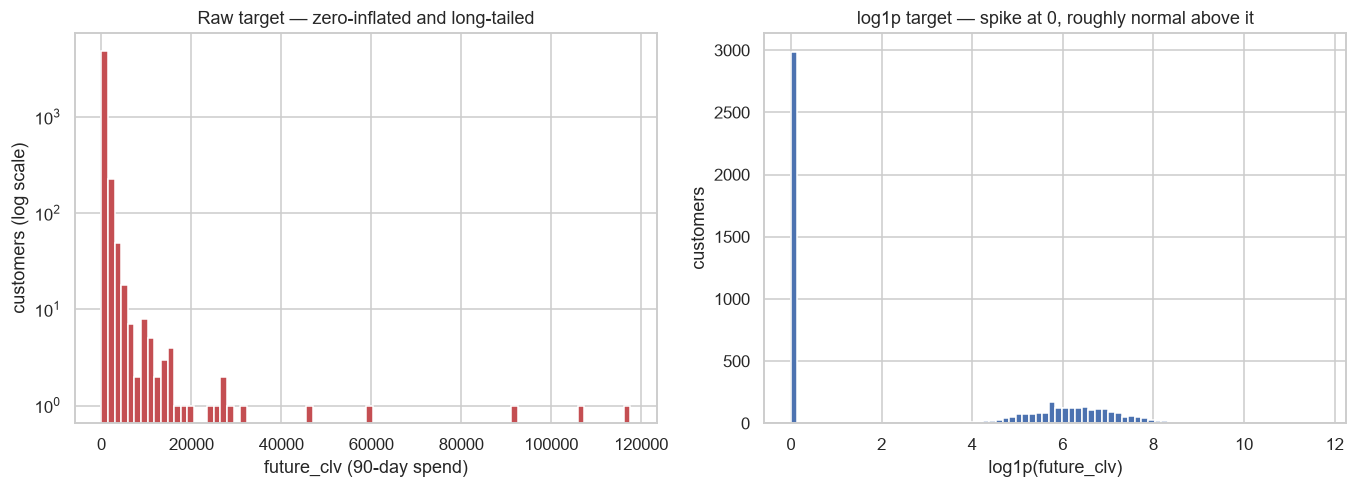

zero-spend share            : 57.2%
among buyers, median spend  : 522.89
among buyers, 99th pct spend: 12,275.44


In [5]:
positive = dataset.loc[dataset[TARGET_COLUMN] > 0, TARGET_COLUMN]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].hist(dataset[TARGET_COLUMN], bins=80, color=sns.color_palette("deep")[3])
axes[0].set_yscale("log")
axes[0].set_xlabel("future_clv (90-day spend)")
axes[0].set_ylabel("customers (log scale)")
axes[0].set_title("Raw target — zero-inflated and long-tailed")

axes[1].hist(np.log1p(dataset[TARGET_COLUMN]), bins=80, color=sns.color_palette("deep")[0])
axes[1].set_xlabel("log1p(future_clv)")
axes[1].set_ylabel("customers")
axes[1].set_title("log1p target — spike at 0, roughly normal above it")
fig.tight_layout()
save_fig(fig, "05_target_distribution.png")
plt.show()

print(f"zero-spend share            : {(dataset[TARGET_COLUMN] == 0).mean():.1%}")
print(f"among buyers, median spend  : {positive.median():,.2f}")
print(f"among buyers, 99th pct spend: {positive.quantile(0.99):,.2f}")

The log1p panel shows the structure the model actually faces: a large point mass at zero
plus an approximately bell-shaped distribution of positive spend. A single regressor has to
cover both, which is why absolute error on the original scale — not R² — is the honest
headline metric.

## 4. Recency, split by whether the customer returns

Recency is the feature most expected to separate returning customers from lapsed ones.
Plotting it against the binary "did they spend anything" outcome shows whether that holds
before any model is fitted.

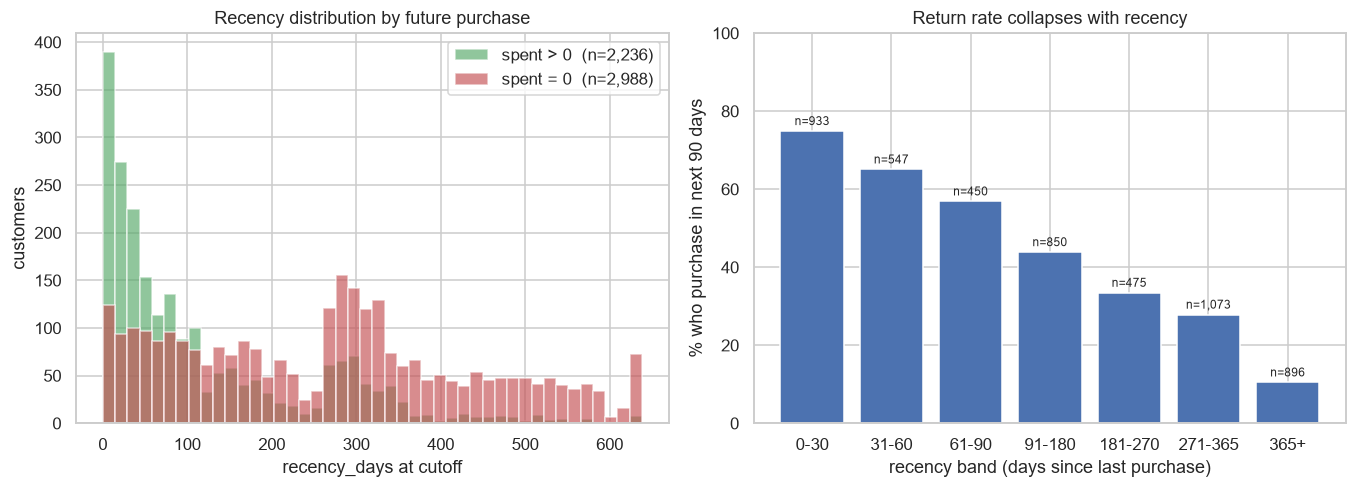

         return_rate       n
band                        
0-30        0.749196   933.0
31-60       0.650823   547.0
61-90       0.568889   450.0
91-180      0.438824   850.0
181-270     0.334737   475.0
271-365     0.278658  1073.0
365+        0.104911   896.0


In [6]:
returned = dataset[TARGET_COLUMN] > 0

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
bins = np.linspace(0, dataset["recency_days"].max(), 45)
axes[0].hist(dataset.loc[returned, "recency_days"], bins=bins, alpha=0.65,
             label=f"spent > 0  (n={returned.sum():,})", color=sns.color_palette("deep")[2])
axes[0].hist(dataset.loc[~returned, "recency_days"], bins=bins, alpha=0.65,
             label=f"spent = 0  (n={(~returned).sum():,})", color=sns.color_palette("deep")[3])
axes[0].set_xlabel("recency_days at cutoff")
axes[0].set_ylabel("customers")
axes[0].set_title("Recency distribution by future purchase")
axes[0].legend()

# Return rate by recency band makes the relationship monotonic and readable.
bands = pd.cut(dataset["recency_days"], bins=[-1, 30, 60, 90, 180, 270, 365, 10_000],
               labels=["0-30", "31-60", "61-90", "91-180", "181-270", "271-365", "365+"])
rate = dataset.assign(band=bands).groupby("band", observed=True).apply(
    lambda g: pd.Series({"return_rate": (g[TARGET_COLUMN] > 0).mean(),
                         "n": len(g)})
)
axes[1].bar(rate.index.astype(str), rate["return_rate"] * 100, color=sns.color_palette("deep")[0])
for x, (r, n) in enumerate(zip(rate["return_rate"], rate["n"])):
    axes[1].text(x, r * 100 + 1.5, f"n={int(n):,}", ha="center", fontsize=8)
axes[1].set_xlabel("recency band (days since last purchase)")
axes[1].set_ylabel("% who purchase in next 90 days")
axes[1].set_title("Return rate collapses with recency")
axes[1].set_ylim(0, 100)
fig.tight_layout()
save_fig(fig, "06_recency_by_future_spend.png")
plt.show()

print(rate.to_string())

## 5. Feature correlations

Checked to understand redundancy among the 11 features. Tree models tolerate correlated
inputs, so nothing is dropped on this basis — but the structure matters when reading SHAP
values later, since correlated features share credit.

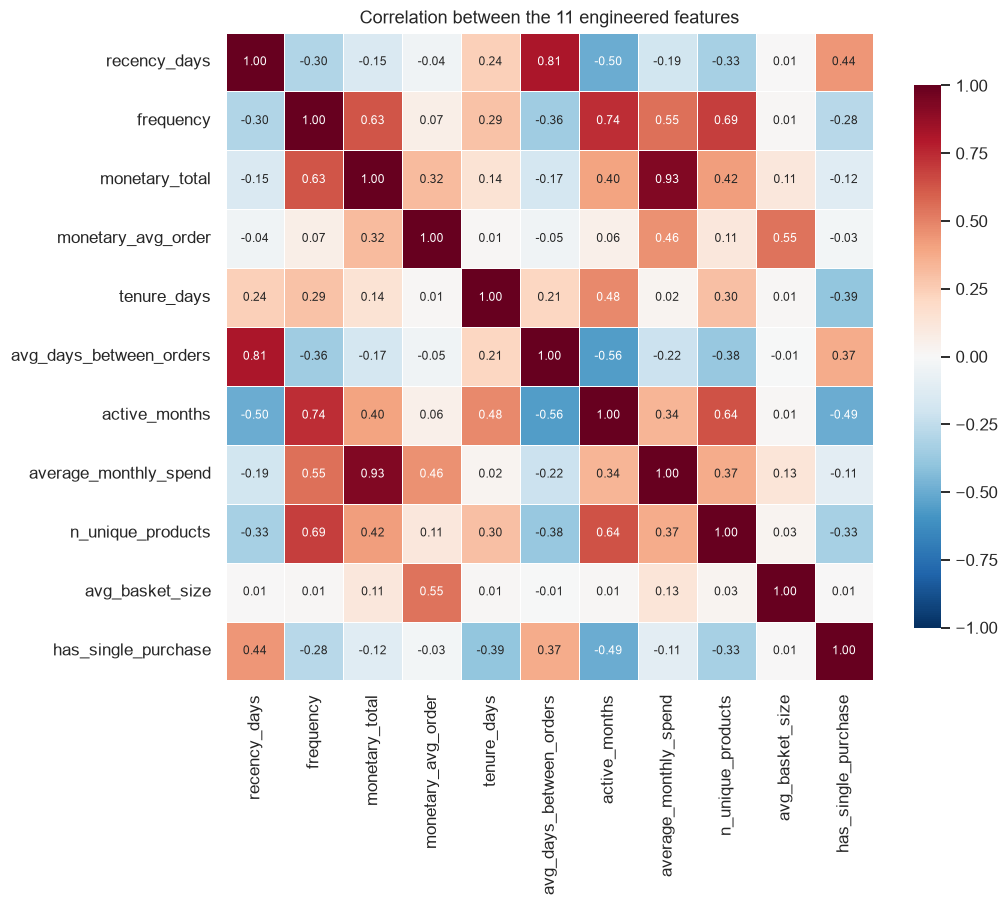

strongest correlated pairs:
monetary_total  average_monthly_spend      0.925078
recency_days    avg_days_between_orders    0.812956
frequency       active_months              0.735132
                n_unique_products          0.692651
active_months   n_unique_products          0.638153
frequency       monetary_total             0.625834


In [7]:
corr = dataset[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlation between the 11 engineered features")
save_fig(fig, "07_feature_correlation.png")
plt.show()

# Surface the strongest pairs explicitly rather than leaving them to be spotted by eye.
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("strongest correlated pairs:")
print(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(6).to_string())

## 6. Average order value vs purchase frequency

The two commercial axes of customer value, coloured by what each customer actually went on
to spend. Log axes because both features span several orders of magnitude.

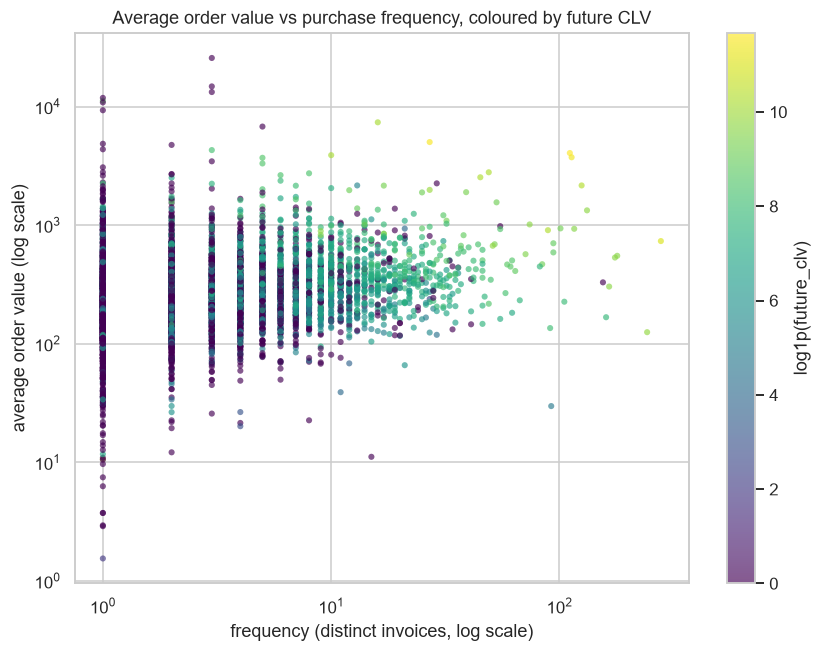

In [8]:
fig, ax = plt.subplots(figsize=(9, 6.5))
sc = ax.scatter(dataset["frequency"], dataset["monetary_avg_order"],
                c=np.log1p(dataset[TARGET_COLUMN]), cmap="viridis",
                s=16, alpha=0.65, edgecolors="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("frequency (distinct invoices, log scale)")
ax.set_ylabel("average order value (log scale)")
ax.set_title("Average order value vs purchase frequency, coloured by future CLV")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("log1p(future_clv)")
save_fig(fig, "08_aov_vs_frequency.png")
plt.show()

High future value concentrates toward the right of the plot: frequency separates future
spend more cleanly than average order value does. Customers with a high AOV but only one or
two orders are noticeably darker — a large single purchase is a much weaker signal of future
value than a habit of returning.

## 7. Final dataset

11 features plus the target, one row per customer.

In [9]:
dataset = build_customer_dataset(transactions)  # same result, via the single entry point
assert list(dataset.columns) == FEATURE_COLUMNS + [TARGET_COLUMN]
assert dataset.isna().sum().sum() == 0
assert dataset.index.is_unique

print(f"shape: {dataset.shape}  ({len(FEATURE_COLUMNS)} features + 1 target)")
dataset.head()

shape: (5224, 12)  (11 features + 1 target)


,recency_days,frequency,monetary_total,monetary_avg_order,tenure_days,avg_days_between_orders,active_months,average_monthly_spend,n_unique_products,avg_basket_size,has_single_purchase,future_clv
Customer ID,,,,,,,,,,,,
12346,225,3,77352.96,25784.320,547,273.500000,3,4304.260914,25,24746.333333,0,0.00
12347,29,6,3402.39,567.065,304,60.800000,6,340.658703,107,349.833333,0,1294.32
12348,148,4,1388.40,347.100,338,112.666667,4,125.027885,24,622.000000,0,270.00
12349,307,2,2221.14,1110.570,489,489.000000,2,138.253474,89,495.500000,0,1457.55
12350,210,1,294.40,294.400,210,210.000000,1,42.670476,16,196.000000,1,0.00


In [10]:
dataset[FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
recency_days,5224.0,203.085184,170.776003,0.000000,49.000000,160.000000,317.000000,638.000000
frequency,5224.0,5.653522,11.064074,1.000000,1.000000,3.000000,6.000000,278.000000
monetary_total,5224.0,2580.157248,11946.389076,1.550000,315.352500,775.745000,2044.392500,451866.970000
monetary_avg_order,5224.0,370.805760,641.614113,1.550000,173.996667,275.556250,408.160000,25784.320000
tenure_days,5224.0,424.283499,178.123355,0.000000,303.000000,465.000000,577.000000,638.000000
avg_days_between_orders,5224.0,219.923262,175.299042,0.000000,73.842857,161.000000,321.250000,638.000000
active_months,5224.0,3.945061,3.933957,1.000000,1.000000,2.000000,5.000000,21.000000
average_monthly_spend,5224.0,178.410332,650.664186,0.092325,29.184704,69.247622,164.357168,21557.524921
n_unique_products,5224.0,74.107580,104.251450,1.000000,18.000000,41.000000,91.000000,2164.000000
avg_basket_size,5224.0,250.038036,1452.564083,1.000000,88.000000,148.900000,253.000000,87167.000000


In [11]:
dataset.to_csv(CUSTOMER_DATASET_PATH, index=True, index_label="Customer ID")
print(f"saved {len(dataset):,} customers -> {CUSTOMER_DATASET_PATH}")

saved 5,224 customers -> C:\Users\monis\Desktop\CLV\data\customer_features.csv
